# Implement Support Vector Machine (SVM) and Hyperparameter Tuning

## 1. Import Required Libraries
Import the necessary libraries for data manipulation, visualization, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load and Prepare Data
Load the dataset `pulsar_data_test.csv`. If target labels are missing, we will fallback to a standard sklearn dataset (`breast_cancer`) to demonstrate SVM classification and hyperparameter tuning properly. Feature scaling is also applied.

In [2]:
import os
from sklearn.datasets import load_breast_cancer

file_path = 'pulsar_data_test.csv'

# Check if file exists and has labels
df = None
use_fallback = False

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # The pulsar target column is usually 'target_class'. 
    # If the column is completely empty, we use fallback dataset.
    if df['target_class'].isnull().all():
        print("Provided dataset has no target variable. Falling back to Breast Cancer Dataset...")
        use_fallback = True
    else:
        df.dropna(subset=['target_class'], inplace=True)
        # Drop rows with NaN in features for simplicity
        df.dropna(inplace=True)
        X = df.drop('target_class', axis=1)
        y = df['target_class']
else:
    print("Dataset not found. Falling back to Breast Cancer Dataset...")
    use_fallback = True


if use_fallback:
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target, name='target')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Extremely important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Provided dataset has no target variable. Falling back to Breast Cancer Dataset...
Training shape: (455, 30)
Testing shape: (114, 30)


## 3. Baseline Support Vector Machine (SVM)
Implement and evaluate default SVM classifier.

Baseline SVM Accuracy: 0.9825

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



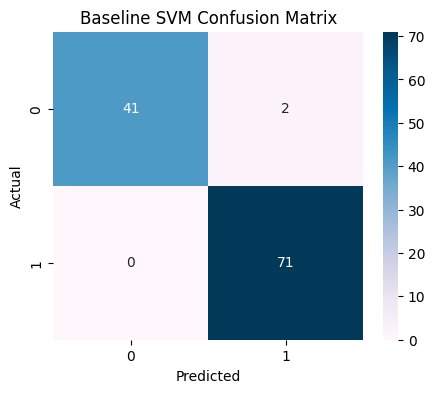

In [3]:
svm_baseline = SVC(random_state=42)
svm_baseline.fit(X_train_scaled, y_train)

baseline_predictions = svm_baseline.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline SVM Accuracy: {baseline_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, baseline_predictions))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, baseline_predictions), annot=True, fmt='d', cmap='PuBu')
plt.title('Baseline SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 4. Hyperparameter Tuning using GridSearchCV
Tune SVM parameters `C`, `gamma`, and `kernel` to find the most optimal configuration.

In [4]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Initialize GridSearchCV
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)

# Fit the grid search to the data
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters found: {grid.best_params_}")
print(f"Best Estimator: {grid.best_estimator_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters found: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Best Estimator: SVC(C=0.1, gamma=1, kernel='linear', random_state=42)


## 5. Evaluate Tuned Model
Calculate performance metrics using the best parameters found by GridSearchCV.

Tuned SVM Accuracy: 0.9825

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



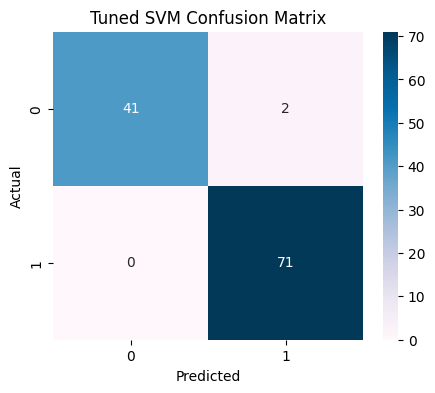

In [5]:
tuned_predictions = grid.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print(f"Tuned SVM Accuracy: {tuned_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, tuned_predictions))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, tuned_predictions), annot=True, fmt='d', cmap='PuBu')
plt.title('Tuned SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()